In [3]:
import sys
sys.path.append('../code')

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import make_network, set_train_parameters, simulate, gaussian_tuning, StimSynapse, get_currents, IonotropicSynapse
from memorycontext_nodendrite_initialize_sweep import get_prior_dict
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

/users/ntolley/.conda/envs/jaxley/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
comp = jx.Compartment()
branch = jx.Branch(comp, ncomp=1)

E_cell = jx.Cell(branch, parents=[-1])
I_cell = jx.Cell(branch, parents=[-1])
context_cell = jx.Cell()
cue_cell = jx.Cell()
rate_cell = jx.Cell()
output_cell = jx.Cell()

num_E_cells = 100
num_I_cells = 50
num_context_cells = 50
num_cue_cells = 50

net_dict = {
    'E': {'num_cells': num_E_cells, 'cell': E_cell},
    'I': {'num_cells': num_I_cells, 'cell': I_cell},
    'context': {'num_cells': num_context_cells, 'cell': context_cell},
    'cue': {'num_cells': num_cue_cells, 'cell': cue_cell},
    'E_rate': {'num_cells': num_E_cells, 'cell': rate_cell},
    'I_rate': {'num_cells': num_I_cells, 'cell': rate_cell},
}

gid_ranges = dict()
cell_list = list()
cell_count = 0
for name, cell_dict in net_dict.items():
    num_cells = cell_dict['num_cells']
    gid_ranges[name] = range(cell_count, cell_count + num_cells)
    cell_list.extend([cell_dict['cell'] for _ in range(num_cells)])
    cell_count += num_cells




In [5]:
# net, gid_ranges = make_network()
# with open('jaxley_net.pkl', 'wb') as f:
#     pickle.dump((net, gid_ranges),f)

# with open('jaxley_net.pkl', 'rb') as f:
#     net, gid_ranges = pickle.load(f)

# num_E_cells, num_I_cells = len(gid_ranges['E']), len(gid_ranges['I'])
# num_cue_cells = len(gid_ranges['cue'])

# parameters, _ = set_train_parameters(net, gid_ranges)
prior_dict = get_prior_dict()

In [6]:
data_path_dendrite = '/users/ntolley/data/ntolley/dendractor/memorycontext_dendrite/'
data_path_nodendrite = '/users/ntolley/data/ntolley/dendractor/memorycontext_nodendrite/'
data_path_nosoma = '/users/ntolley/data/ntolley/dendractor/memorycontext_nosoma/'
data_path_lowaxialres = '/users/ntolley/data/ntolley/dendractor/memorycontext_lowaxialres/'


t_max = 2000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

In [7]:
input_list = jnp.array([[-2,-2,1], [2,2,1], [-2, 2,1], [2,-2,1],
                       [-2,-2,-1], [2,2,-1], [-2, 2,-1], [2,-2,-1]])
num_cond = input_list.shape[0]
input_data = [get_currents(input_list[idx], gid_ranges, t_max=t_max, dt=0.025) for idx in range(num_cond)]
targets = np.concatenate([input_data[idx][2][:, ::10] for idx in range(num_cond)], axis=1).T


In [13]:
def get_opt_data(data_path):
    print(f'Loading data from: {data_path}')
    theta_list = list()
    error_list = list()
    band_power_list = list()

    num_flows = 5
    for flow_idx in range(num_flows):
        print(f'Flow {flow_idx}')
        theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
        error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')
        band_power_avg = np.load(f'{data_path}/flow_band_power_{flow_idx}.npy')


        rate_gids = list(gid_ranges['E_rate']) + list(gid_ranges['I_rate'])
        voltage_gids = list(gid_ranges['E'])

        # if flow_idx == num_flows - 1:
        #     x_out = np.load(f'{data_path}/x_out_{flow_idx}.npy')
        #     rates = x_out[:, rate_gids, :]
        #     voltages = x_out[:, voltage_gids, :]
        #     num_sims, num_neurons, num_samples = rates.shape
        # theta_list.append(theta)
        error_list.append(error)
        band_power_list.append(band_power_avg)


    error_sort = np.argsort(error)

    # rates_stacked = rates.reshape((num_sims * num_neurons, num_samples))
    # freqs, spectrum = compute_spectrum(rates_stacked, fs=fs, nperseg=fs*5)
    # spectrum = spectrum.reshape((num_sims, num_neurons, -1))

    res_dict = {'theta_list': theta_list, 'error_list': error_list, 'band_power_list': band_power_list, 'error_sort': error_sort, 
                # 'freqs': freqs, 'spectrum': spectrum, 'rates_stacked': rates_stacked
                }

    return res_dict

In [14]:
res_dict_dendrite = get_opt_data(data_path_dendrite)
res_dict_nodendrite = get_opt_data(data_path_nodendrite)
res_dict_nosoma = get_opt_data(data_path_nosoma)
res_dict_lowaxialres = get_opt_data(data_path_lowaxialres)

Loading data from: /users/ntolley/data/ntolley/dendractor/memorycontext_dendrite/
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Loading data from: /users/ntolley/data/ntolley/dendractor/memorycontext_nodendrite/
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Loading data from: /users/ntolley/data/ntolley/dendractor/memorycontext_nosoma/
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4
Loading data from: /users/ntolley/data/ntolley/dendractor/memorycontext_lowaxialres/
Flow 0
Flow 1
Flow 2
Flow 3
Flow 4


In [15]:
labelsize = 16
ticksize = 12
legendsize = 12
linewidth = 2
ymin, ymax = 1e-10, 1

freqs = res_dict_dendrite['freqs']
x_max = 100
freq_mask = freqs < x_max

dendrite_spectrum_avg = np.mean(res_dict_dendrite['spectrum'], axis=(0,1))
nodendrite_spectrum_avg = np.mean(res_dict_nodendrite['spectrum'], axis=(0,1))

plt.plot(freqs[freq_mask], dendrite_spectrum_avg[freq_mask], linewidth=linewidth, label='Dendrite', color='k')
plt.plot(freqs[freq_mask], nodendrite_spectrum_avg[freq_mask], linewidth=linewidth, label='No Dendrite', color='r')

# plt.xlim(-10, x_max + 10)
plt.yscale('log')
plt.xscale('log')

plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)
plt.legend(fontsize=legendsize)
plt.ylabel('Power', fontsize=labelsize)
plt.xlabel('Frequency (Hz)', fontsize=labelsize)
plt.savefig('../figures/memorycontext_psd_comparison.svg')

KeyError: 'freqs'

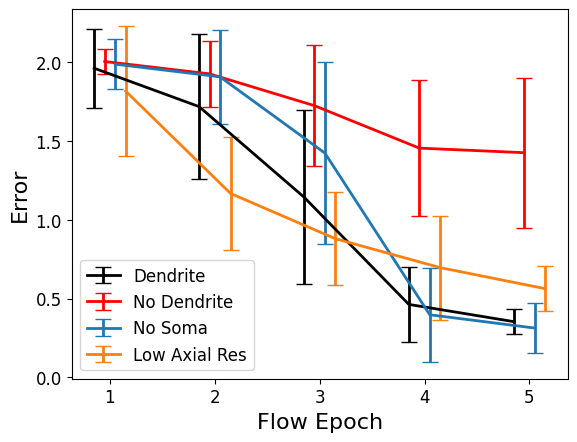

In [20]:
labelsize = 16
ticksize = 12
legendsize = 12
linewidth = 2


dendrite_error_avg = np.mean(np.array(res_dict_dendrite['error_list']), axis=1)
dendrite_error_std = np.std(np.array(res_dict_dendrite['error_list']), axis=1)

nodendrite_error_avg = np.mean(np.array(res_dict_nodendrite['error_list']), axis=1)
nodendrite_error_std = np.std(np.array(res_dict_nodendrite['error_list']), axis=1)

nosoma_error_avg = np.mean(np.array(res_dict_nosoma['error_list']), axis=1)
nosoma_error_std = np.std(np.array(res_dict_nosoma['error_list']), axis=1)

lowaxialres_error_avg = np.mean(np.array(res_dict_lowaxialres['error_list']), axis=1)
lowaxialres_error_std = np.std(np.array(res_dict_lowaxialres['error_list']), axis=1)


xticks = np.array(list(range(1,6)))
plt.errorbar(x=xticks-0.15, y=dendrite_error_avg, yerr=dendrite_error_std, linewidth=linewidth, label='Dendrite', color='k', capsize=6)
plt.errorbar(x=xticks-0.05, y=nodendrite_error_avg, yerr=nodendrite_error_std, linewidth=linewidth, label='No Dendrite', color='r', capsize=6)
plt.errorbar(x=xticks+0.05, y=nosoma_error_avg, yerr=nosoma_error_std, linewidth=linewidth, label='No Soma', color='C0', capsize=6)
plt.errorbar(x=xticks+0.15, y=lowaxialres_error_avg, yerr=lowaxialres_error_std, linewidth=linewidth, label='Low Axial Res', color='C1', capsize=6)


plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)
plt.legend(fontsize=legendsize)
plt.ylabel('Error', fontsize=labelsize)
plt.xlabel('Flow Epoch', fontsize=labelsize)
plt.savefig('../figures/memorycontext_error_comparison.svg')

In [26]:
opt_dict = {'flow_idx': list(range(5)),
            'dendrite_error_avg': dendrite_error_avg, 'dendrite_error_std': dendrite_error_std,
            'nodendrite_error_avg': nodendrite_error_avg, 'nodendrite_error_std': nodendrite_error_std,
            }
opt_df = pd.DataFrame(opt_dict)
opt_df.to_csv('../data/memorycontext_optimization_comparison.csv')


,flow_idx,error_avg,error_std,band_power_avg,band_power_std
0,0,1.960639,0.250041,0.001343,0.004146
1,1,1.717358,0.459558,0.002644,0.004575
2,2,1.143728,0.549151,0.004072,0.004437
3,3,0.463161,0.235576,0.011096,0.004789
4,4,0.353937,0.078613,0.016452,0.002138
